# Introduction

This tutorial requires ipykernel and Jupyter Notebooks. It covers the basics of the ``pyFiberPhotometry`` package for photometry data processing, handling, and analysis.

While using this package does not require much coding or technical knowledge, it is the good to get familiar with:
* [Basic Python](https://www.w3schools.com/python/default.asp).

* The [numpy package](https://www.w3schools.com/python/numpy/default.asp) and numpy arrays.

* The [pandas package](https://www.w3schools.com/python/pandas/) and pandas DataFrames.

* The [components of photometry measurements]().

* (Optional) the [plotnine package](https://plotnine.org) as that is what this package uses as a plotting backend.

``pyFiberPhotometry`` is organized into 4 main modules:

* **PhotometryLoader** - classes to load various photometry data formats.

* **PhotometryExperiment** - a class for processing and windowing photometry experiments with many avaliable preprocessing methods.

* **PhotometryData** - a class holding trial-wise signals and metadata with advanced filtering, averaging, windowing, and analysis functionality.

* **PhotometryPipeline** - a class for easy, highly-customizable bulk processing of photometry data.

# Setup

First we need to import the necessary packages. If you have trouble importing any of the ``pyFiberPhotometry`` modules check to make sure your enviroment is active in the Jupyter Notebook and all dependencies are install properly (see the [Installation]() guide on the docs).

In [6]:
import numpy as np
import pandas as pd

from pyFiberPhotometry import PhotometryExperiment, PhotometryData, PhotometryPipeline, SimulatedPhotometry

# 0. Generating Data

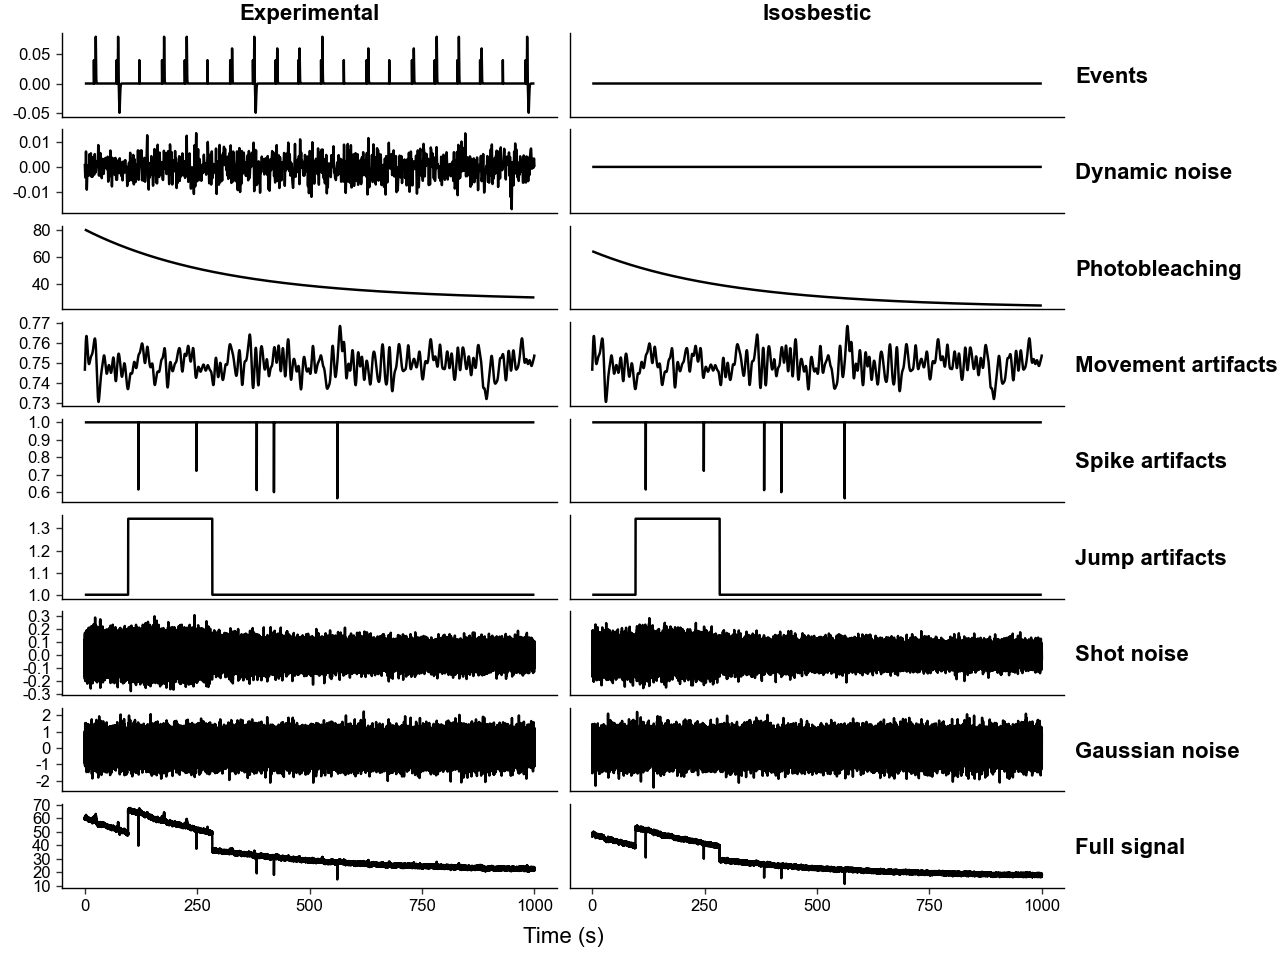

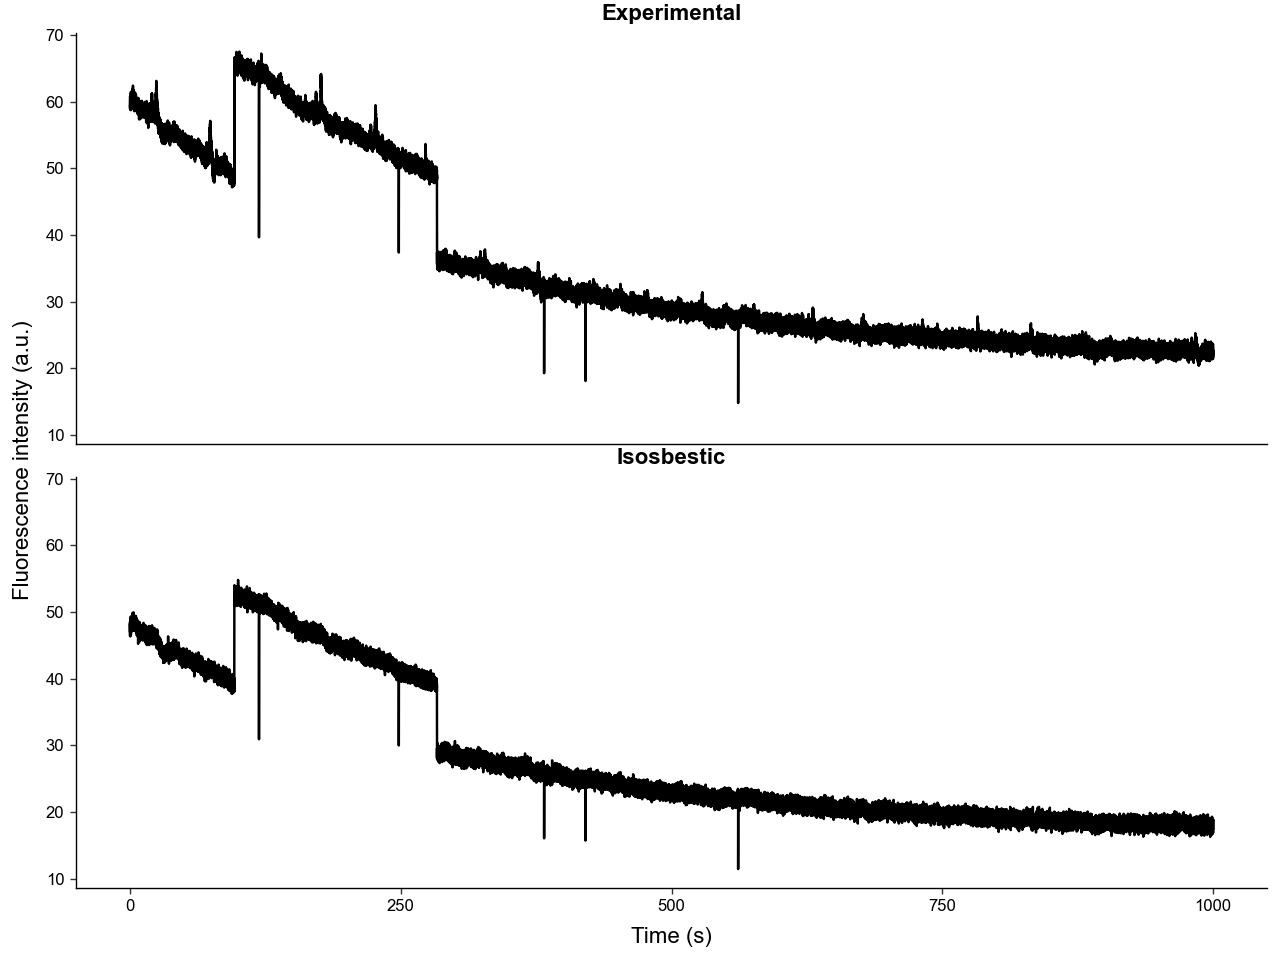

In [7]:
sim = SimulatedPhotometry.from_parameters(
    length_sec=1000,
    frequency=100,

    bleaching_params_exp = { 'alpha1': 50, 'alpha2': 20, 'tau1': 300, 'tau2': 10000, 'B_floor': 10 },
    iso_bleach_scale=0.8,
    iso_bleach_offset=None,

    event_label='trial_cue',
    n_events=20,
    event_kernel=SimulatedPhotometry.kernel_gamma,
    event_amplitude=0.04,
    event_kernel_params={'tau_sec':0.1},
    event_buffer_sec=20.0,

    movement_attenuation=0.5,
    attenuation_cutoff_hz=0.1,

    photons_per_unit=1e4,
    gaussian_noise_scale=0.5,

    dynamic_noise_amplitude=0.004,
    dynamic_noise_center=0.0,
    dynamic_noise_frequency=1.0,

    n_spike_artifacts=5,
    spike_amplitude_range=(-0.5, -0.2),

    n_jump_artifacts=1,
    jump_amplitude_range=(0.3, 0.35),
    jump_duration_range=(100, 200),

)

sim.add_event_relative_to(
    relative_to='trial_cue',
    time_range=(2, 4),
    overall_prob=0.8,
    labels=['lever1', 'lever2'],
    choice_probs=[0.5, 0.5],
    amplitudes=[0.08, 0.06],
    kernel_funcs=[
        SimulatedPhotometry.kernel_gamma, 
        SimulatedPhotometry.kernel_gamma
    ],
    kernel_params=[
        {'shape_k':5, 'tau_sec':0.2},
        {'shape_k':5, 'tau_sec':0.2},
    ],
)

sim.add_event_relative_to(
    relative_to='lever1',
    time_range=(1, 1.5),
    overall_prob=0.5,
    labels=['shock'],
    amplitudes=[-0.05],
    kernel_funcs=[
        SimulatedPhotometry.kernel_gamma
    ],
    kernel_params=[
        {'shape_k':10, 'tau_sec':0.3},
    ],
)

sim.plot_layers(condensed=False).show()
sim.plot_traces().show()

sim.plot

In [9]:
exp = sim.to_PhotometryExperiment()
exp.to_wide_dataframe(export_events=True).to_csv('data/experiments/example_experiment.csv', index=False)

# 1. Loading Data

We will begin by learning how to load data from a CSV file into the ``pyFiberPhotometry`` package. The CSV file contains the columns: "time", containing timepoints; "raw_signal" and "raw_isosbestic", containing the signal from experimental and isosbestic wavelengths; and "trial_cue", "lever1", "lever2", and "shock", containing event timestamps.

In [10]:
# import the loader class for your specifc data format
from pyFiberPhotometry import CSVLoader

# initialize the loader
loader = CSVLoader(
    csv= 'data/experiments/example_experiment.csv',
    time_col= 'time',
    signal_col= 'raw_signal',
    isosbestic_col= 'raw_isosbestic',
    event_cols= ['trial_cue', 'lever1', 'lever2', 'shock']
)

# extract the data and load it into the PhotometryExperiment class
exp = loader.load()

# see if data was successfully loaded
exp

Dual channel photometry experiment with 100000 timepoints.

We can also load in important metadata from annotation files. Currently supported formats are JSON and YML. Built-in loaders also automatically pass down the source file to experimental metadata.

In [11]:
# initialize the loader
loader = CSVLoader(
    csv= 'data/experiments/example_experiment.csv',
    time_col= 'time',
    signal_col= 'raw_signal',
    isosbestic_col= 'raw_isosbestic',
    event_cols= ['trial_cue', 'lever1', 'lever2', 'shock'],
    annotation_file='data/experiments/example_annotation.json',
    annotation_handler='json',
)

# extract the data and load it into the PhotometryExperiment class
exp = loader.load()

# see what matedata was picked up
exp.metadata

{'source': 'data/experiments/example_experiment.csv',
 'subject': 'animal_1',
 'sex': 'male',
 'age': 'young'}

Other built in loaders, like the ``TDTLoader``, behave very similarly to the ``CSVLoader``.

# 2. Signal processing
Once you have your data loaded, the next step in most workflows is to preprocess the signals. The exact steps depend on whether or not the experiment conatins an isosbestic trace:
* **Dual-channel** experiments have an isosbestic reference signal. They are generally more common and produce a cleaner signal by using the concentration agnostic isosbestic signal to correct signal artifacts and photobleaching. 

* **Single-channel** experiments do NOT have an isosbestic signal. They are usually less common and require extra steps to correct for photobleaching and artifacts.

## 2.1. Dual-channel processing

The general scheme for processing a **dual-channel** experiment is:

1. Apply a low-pass filter to both the experimental and isosbestic signals to filter out high frequency noise.

2. Fit the isosbestic to the experimental signal using a linear equation: $\text{Exp} = \beta_1 \cdot \text{Iso} + \beta_0$.

3. Apply an isosbestic correction either ``dF/F`` or ``dF``.
    * ``dF/F`` $= (\text{Exp.} - \text{Iso}_\text{ fitted}) / \text{Iso}_\text{ fitted}$
    * ``dF`` $= (\text{Exp.} - \text{Iso}_\text{ fitted})$

4. Optionally normalize the entire signal.

For most experiments the following parameters are recommended based on the findings in [Keevers et al., 2025](https://doi.org/10.1117/1.NPh.12.2.025003):
* A low-pass filter with a cutoff of 3 Hz and order of 4.
* Fitting the isosbestic curve with iteratively-reweighted least squares (IRLS).
* Using the ``dF/F`` correction.
* No whole-trial normalization.

Let's begin by loading in our same example experiment from the previous section.

In [42]:
loader = CSVLoader(
    csv= 'data/experiments/example_experiment.csv',
    time_col= 'time',
    signal_col= 'raw_signal',
    isosbestic_col= 'raw_isosbestic',
    event_cols= ['trial_cue', 'lever1', 'lever2', 'shock'],
    annotation_file='data/experiments/example_annotation.json',
    annotation_handler='json',
)
exp = loader.load()

# this time we will assign an ID to our experiment
exp.id = 'Dual-channel example'

Now we can examine the raw traces with ``.plot_dashboard()``.

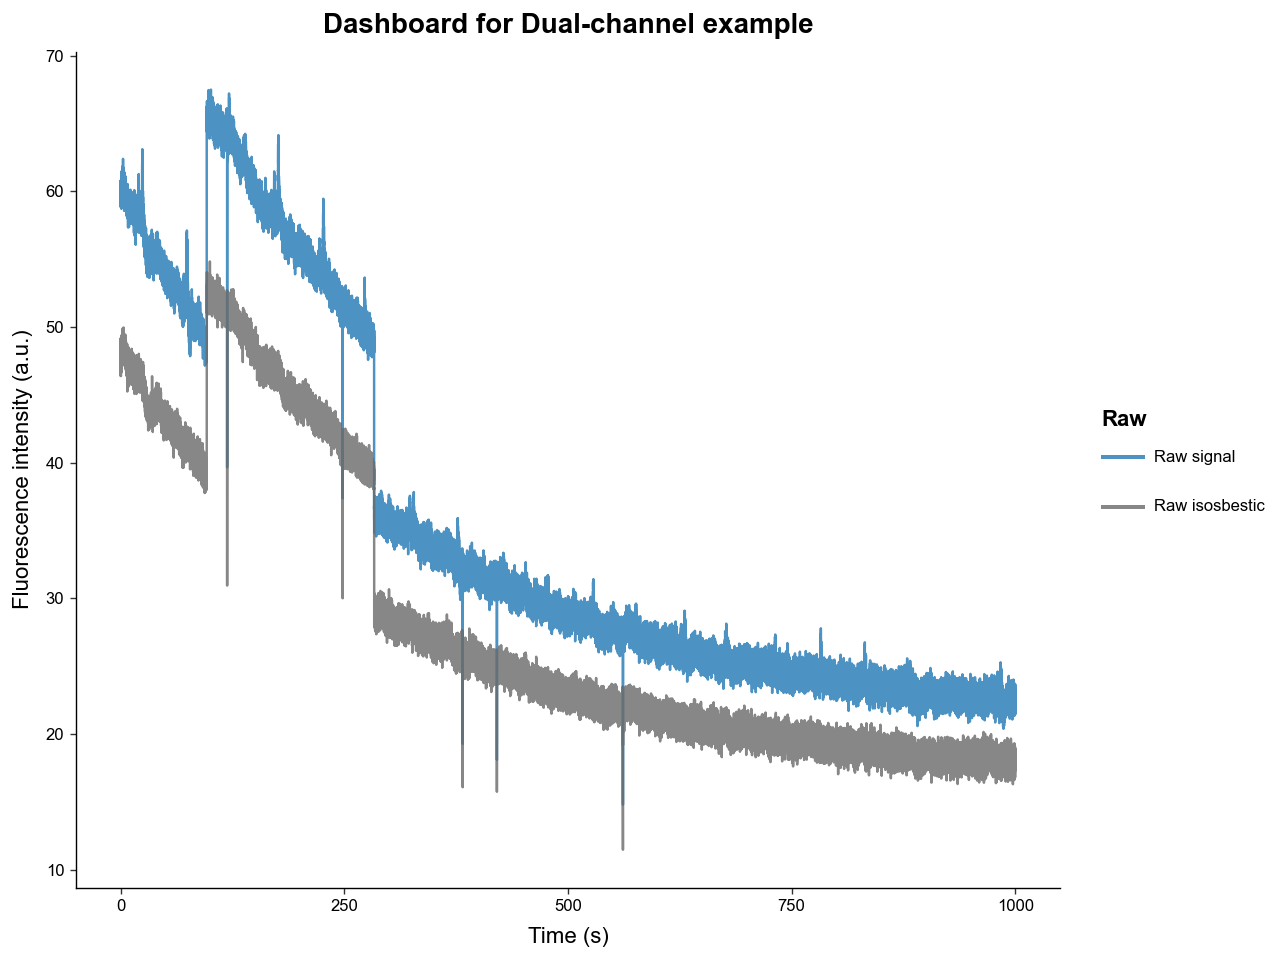

In [43]:
exp.plot_dashboard()

We can see that the raw experimental and isosbestic signals have significant photobleaching attenuation and movement artifacts. Notice, however, that the stark movement artifacts are shared between experimental and isosbestic signals. This is why using the isosbestic as a reference channel is an effective way to correct for artifacts.

Now is a good time to mention that all the ploting methods in this package return a ``ggplot`` object from the ``plotnine`` package, that can be directly modified to fit you publication or presentation needs. For example:

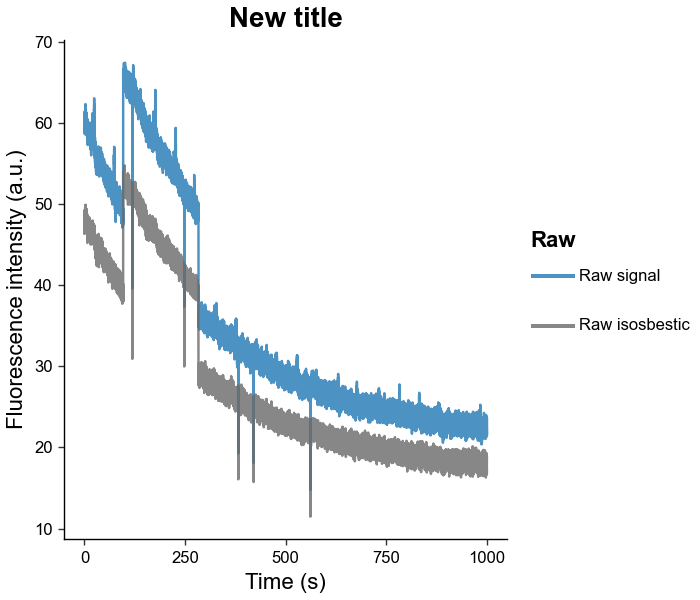

In [44]:
from plotnine import ggplot, theme, labs

p: ggplot = exp.plot_dashboard()
p = (
    p
    + labs(title='New title')
    + theme(figure_size=(3.5, 3))
)
p.show()

Now let's process the signal using the ``.preprocess_signal()`` methods. This method will:
* Apply a low-pass [butterworth filter](https://en.wikipedia.org/wiki/Butterworth_filter) with a specified cutoff frequency and order

* Fit the isosbestic to the experimental signal using a customizable method

* Apply the isosbestic correction

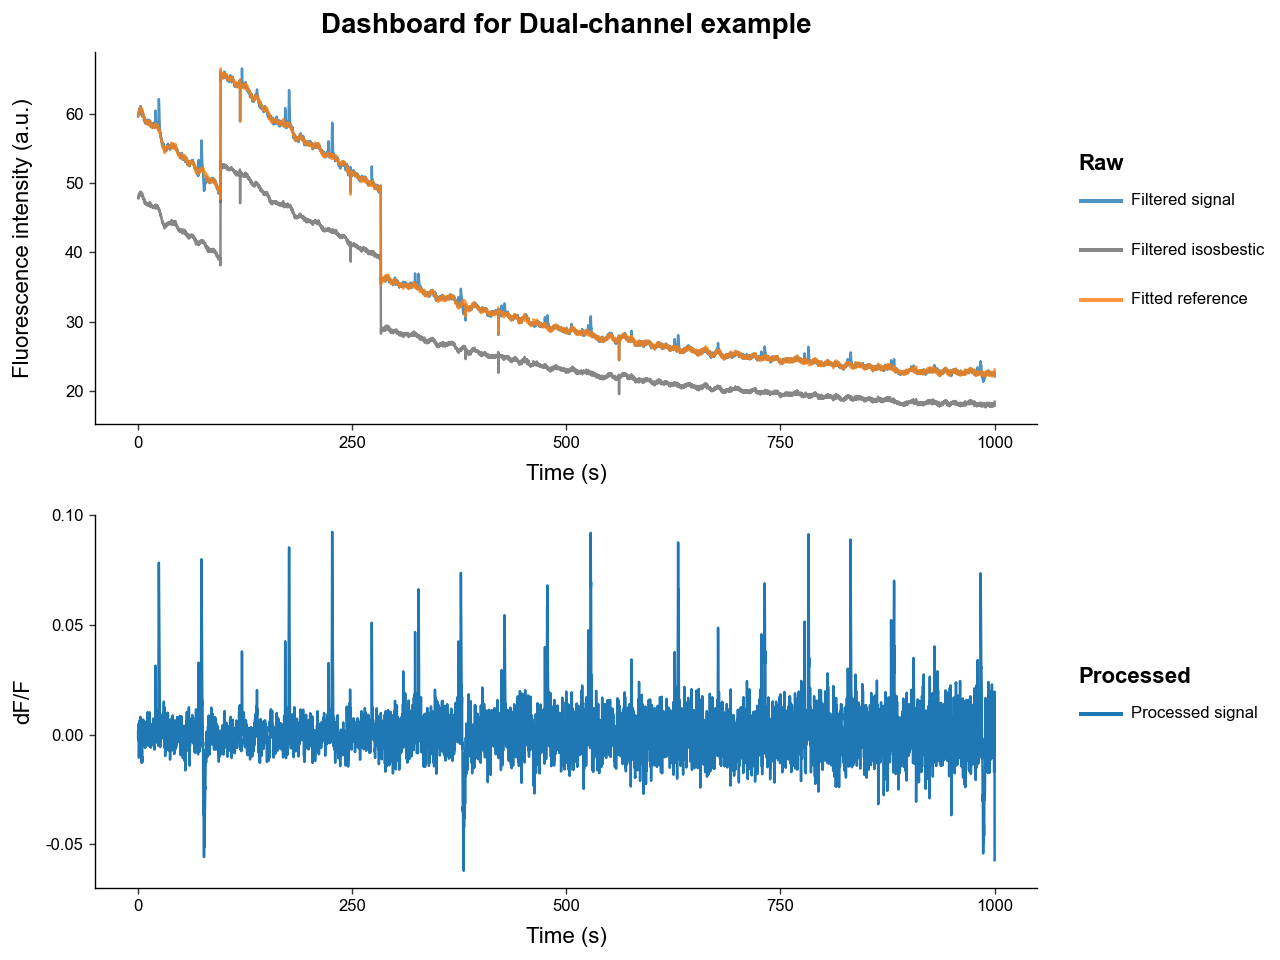

In [15]:
exp.preprocess_signal(
    # lowpass butterworth params
    cutoff_frequency=3,
    order=4,

    # correction method and isosbestic fit params
    correction_method='dF/F',
    fit_using='IRLS',
    maxiter=2000,
    c=2,

    # artifact correction params (mostly useful for single channel experiments)
    artifact_detector=None,
    artifact_corrector=None,

    channel_mode='auto'
)

# examine the fitted isosbestic and processed signal
exp.plot_dashboard(raw=False)

Notice how:

* The filtered signals have much less high-frequency noise due to low-pass filtering.

* The fitted isosbestic overlaps very nicely with the experimental signal except for some peak transients.

* The processed signal is free of photobleaching attenuation and movement artifacts.

* The transient spikes in the processed signal have a relatively stable amplitudes over time, while the magnitude of noise increases. This is because photobleaching attenuation decreases the signal-to-noise ratio.

Once ``.preprocess_signal()`` is run, the ``PhotometryExperiment`` object automatically populates its ``.metadata`` with reference fitting and correction type information.

In [16]:
# view metadata
exp.metadata

{'source': 'data/experiments/example_experiment.csv',
 'subject': 'animal_1',
 'sex': 'male',
 'age': 'young',
 'reference_fit': {'type': 'isosbestic',
  'r2_val': 0.9990783751778679,
  'coeffs': array([-0.01397495,  1.25023965])},
 'correction_method': 'dF/F'}

Let's now compare the ``dF/F`` correction to the ``dF`` correction.

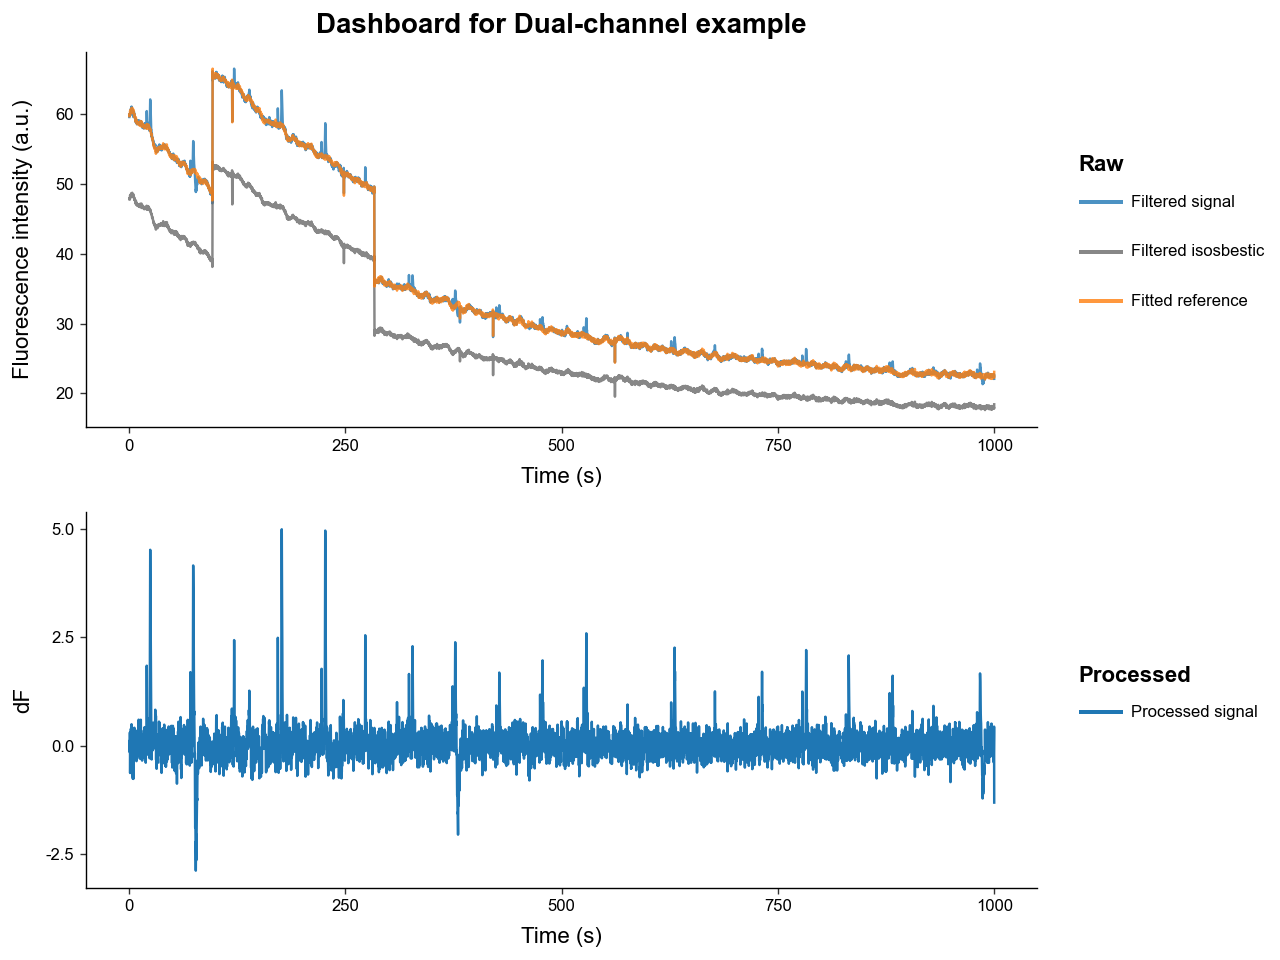

In [17]:
exp.preprocess_signal(
    cutoff_frequency=3,
    order=4,
    # same parameters as before but with dF
    correction_method='dF',
    fit_using='IRLS',
    maxiter=2000,
    c=2,
    artifact_detector=None,
    artifact_corrector=None,
)

exp.plot_dashboard(raw=False)

Now notice how:

* The noise is constant while the transient peaks are decreasing in amplitude.

* This is because the ``dF`` correction does not correct for the photobleaching attenuation of the signal.

## 2.2. Single-channel processing

The general scheme for processing a **single-channel** experiment is:

1. Apply a low-pass filter to both the experimental signal to filter out high frequency noise.

2. Fit a photobleaching curve to the experimental signal.
    * This package uses a negative biexponential equation to model photobleaching: $\quad \alpha_1 \exp(\beta_1 t )+ \alpha_2 \exp(\beta_2 t)$

3. Apply an reference correction either ``dB/B`` or ``dB``.
    * ``dF/F`` $= (\text{Exp.} - \text{B}_\text{ fitted}) / \text{B}_\text{ fitted}$
    * ``dF`` $= (\text{Exp.} - \text{B}_\text{ fitted})$

4. Detect and correct artifacts.
    * Since a reference channel isosbestic curve that shares artifacts is not present manual artifact detection and correction is required.

We will begin by loading our example experiment like in 2.1, but we will not load the isosbestic trace. Notice how our dashboard plot only contains the raw experimental signal now.

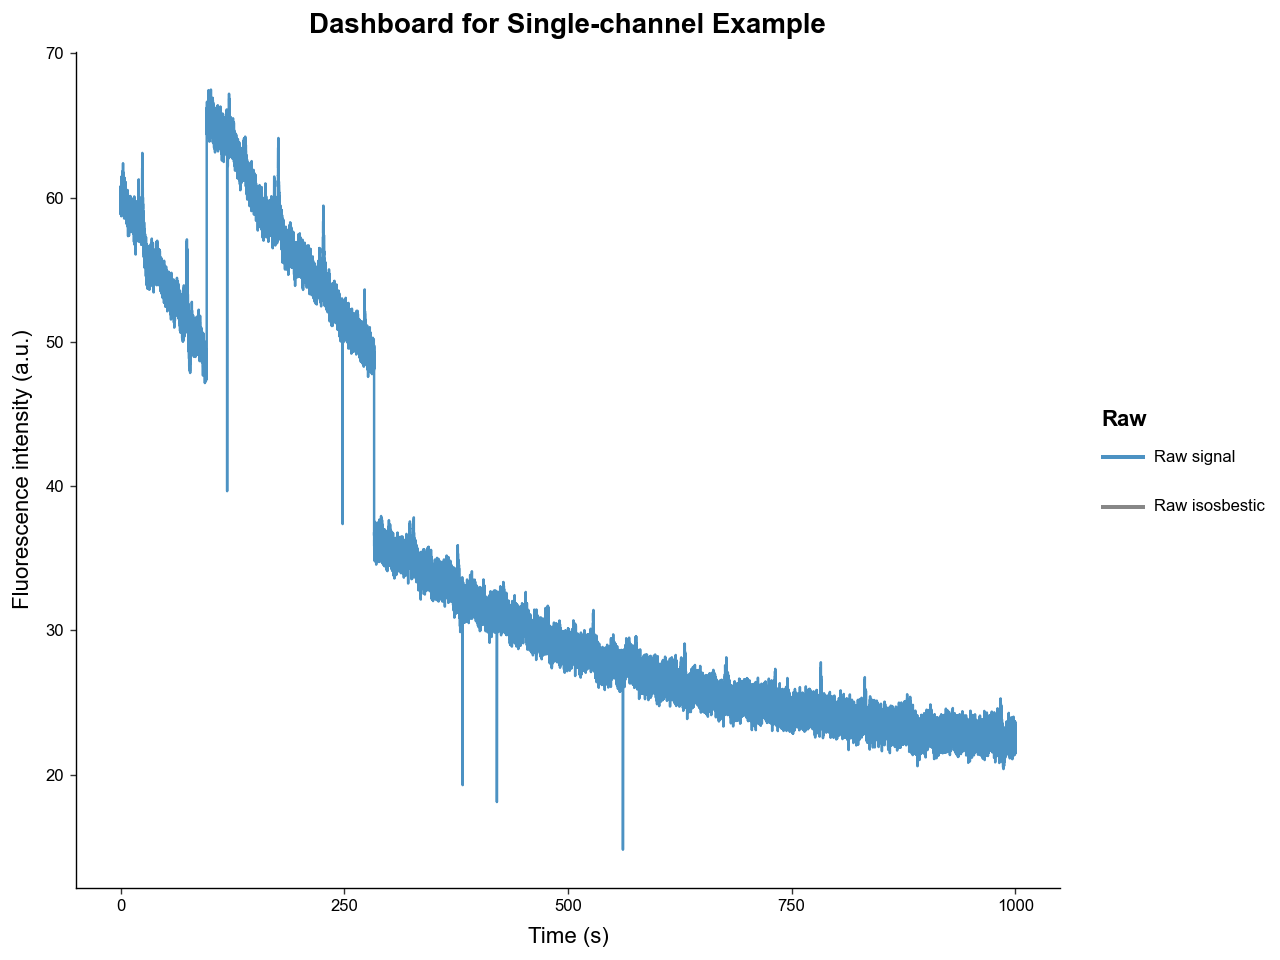

In [18]:
# initialize the loader
loader = CSVLoader(
    csv = 'data/experiments/example_experiment.csv',
    time_col = 'time',
    signal_col = 'raw_signal',
    isosbestic_col = None,
    event_cols = ['trial_cue', 'lever1', 'lever2', 'shock']
)

# extract the data and load it into the PhotometryExperiment class
exp = loader.load()
exp.id = 'Single-channel Example'
exp.plot_dashboard()

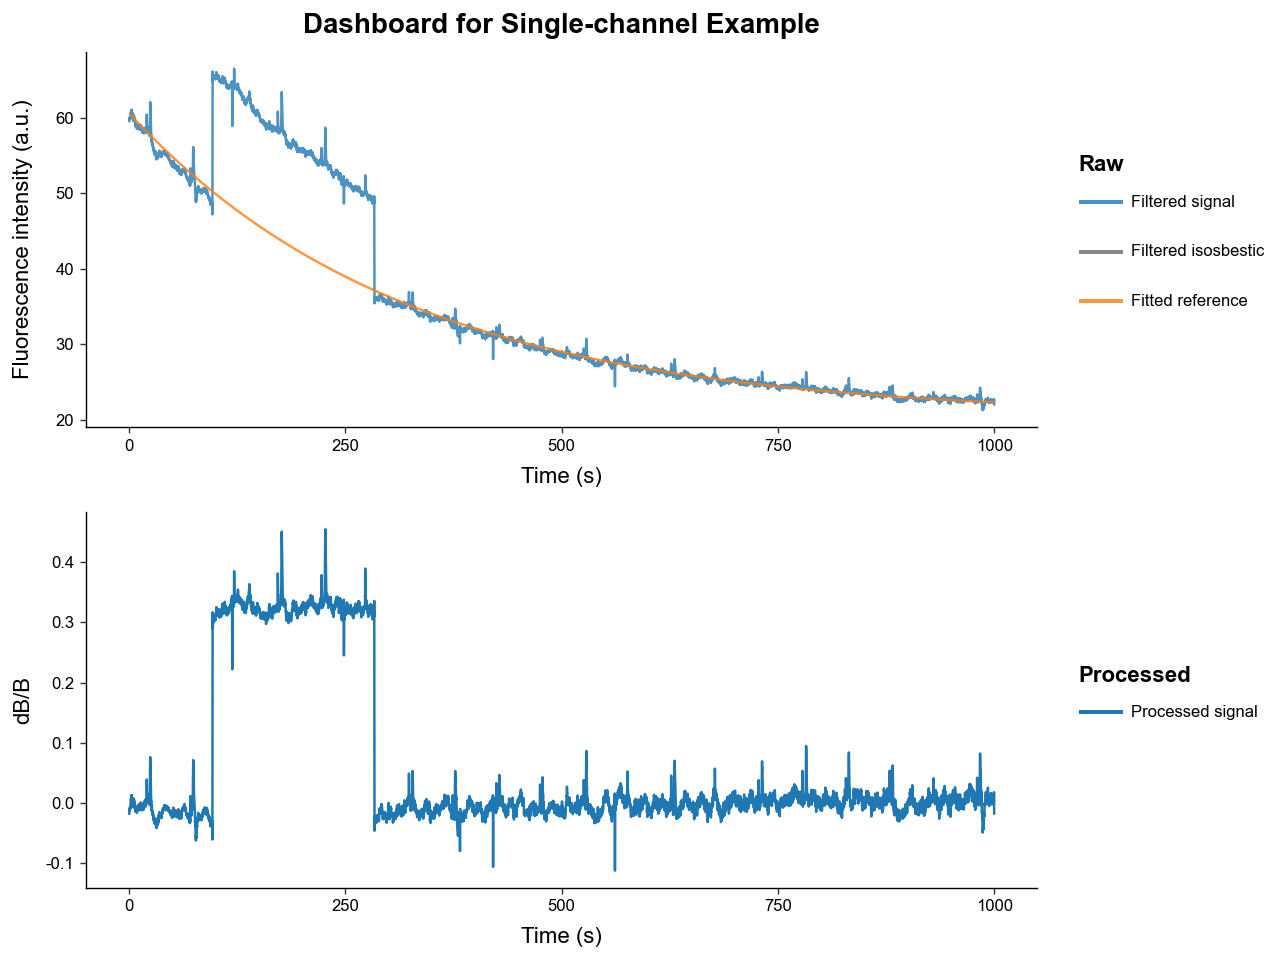

In [19]:
exp.preprocess_signal(
    # lowpass butterworth params
    cutoff_frequency=3,
    order=4,

    # correction method and isosbestic fit params
    correction_method='dB/B',
    fit_using='IRLS',
    maxiter=1000,
    c=2,
)
exp.plot_dashboard()

Our photobleaching curve fit very well. However, our processed signal still contains major artifacts - most prominently one large "jump" artifact.

To correct those artifacts, we need to setup our artifact handlers from the ``artifact`` module. The two most common types of artifacts are:
* Spike artifacts: sharp pings that readily return to baseline

* Jump artifacts: sharp changes that change the baseline value of signal for an extended period

Below we will use a detector the uses outlier derivative score-based detection and a corrector that fills artifacts with a spline interpolator.

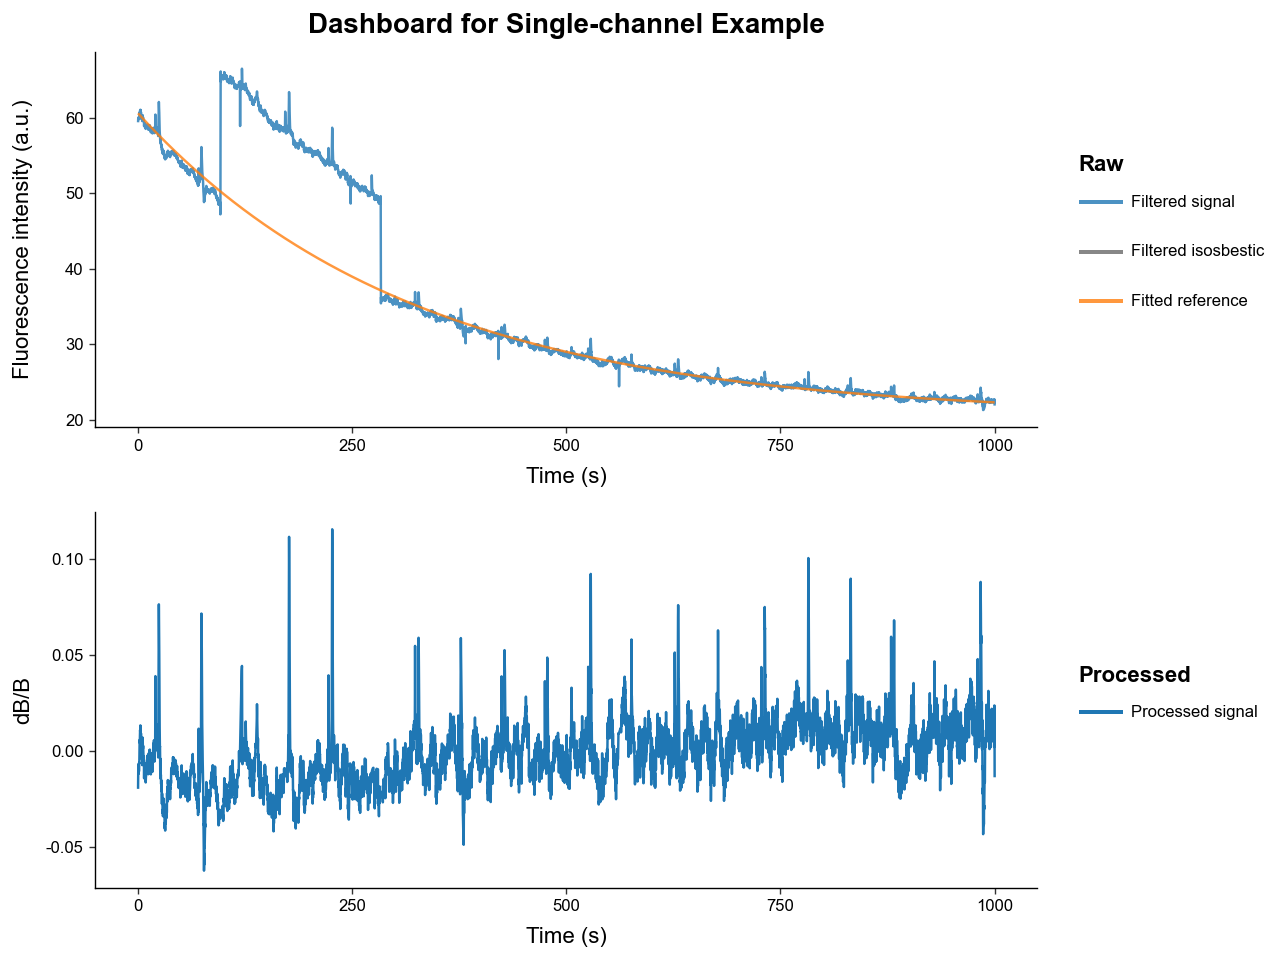

In [20]:
# import artifact handlers
from pyFiberPhotometry.analysis.artifact import ODS_Detector, Spline_Corrector

# instantiate artifact detector and corrector
detector = ODS_Detector(
    score_threshold=5,
    jump_score_threshold=5,
    expand_sec=(0.5, 2),
    buffer_sec=1.5,
    n_chunks=20,
)

corrector = Spline_Corrector(
    anchor_sec=(0.2, 0.2),
    correct_spikes=True,
    correct_jumps=True,
)

exp.preprocess_signal(
    # lowpass butterworth params
    cutoff_frequency=3,
    order=4,

    # correction method and isosbestic fit params
    correction_method='dB/B',
    fit_using='IRLS',
    maxiter=1000,
    c=2,

    # pass in our artifact handlers
    artifact_detector=detector,
    artifact_corrector=corrector,
)
exp.plot_dashboard()

We can see the recovered signal with artifact correction has much less artifacting. Manual artifact correction is not perfect so using an isosbestic reference signal is preferred.

# 3. Trial Windowing

Once we have our processed, hopefully artifact-free, signal, we usually want to window the whole it into many smalled trials based on event or manual timestamps.

First, let's reload and process our example signal and inspect which events are present.

In [21]:
# load
loader = CSVLoader(
    csv= 'data/experiments/example_experiment.csv',
    time_col= 'time',
    signal_col= 'raw_signal',
    isosbestic_col= 'raw_isosbestic',
    event_cols= ['trial_cue', 'lever1', 'lever2', 'shock'],
    annotation_file='data/experiments/example_annotation.json',
    annotation_handler='json',
)
exp = loader.load()
exp.id = 'Trial Extraction Example'

# process
exp.preprocess_signal(
    correction_method='dF/F',
    fit_using='IRLS',
)

# examine events present
exp.event_labels

['trial_cue', 'lever1', 'lever2', 'shock']

This simulated dataset models a risky-decision making behavioral experiment wherein:
*  A light turns on signifying the beginning of trial, represented by "trial_cue".

* Then the rat has between 2 and 4 seconds after the "trial_cue" to choose 1 of 2 levers that when pressed register as "lever1" and "lever2".

* "lever1" gives the rat a large food reward but there is a chance of the rat being shocked immediately after, represented by the "shock" event.

* "lever2" gives the rat a small food reward.

To slice the processed signal in ``PhotometryExperiment`` into a many events we use the method ``.extract_trial_data()``, which holds its result as a ``PhotometryData`` object in the ``.trial_data`` attribute.

In [22]:
exp.extract_trial_data(
    # what event should we consider the "start" of a trial
    align_to='trial_cue',

    # what event(s) within a trial do we want to center on, i.e. be 0s
    # they should be mutually exclusive and if none are present in a trial it is centered to "align_to"
    center_on=['lever1', 'lever2'],

    # how long in seconds should our trials be relative to "center_on"
    trial_bounds=(-8, 8),

    # expected range of our events relative to "align_to"
    # if the value is None, the range defaults to "trial_bounds"
    event_tolerences={
        'lever1':(2, 4),
        'lever2':(2, 4),
        'shock':None,
    },

    # optional bounds for a "baseline" relative to the "align_to" event in seconds
    baseline_bounds=None,

    # which trial-wise normalization should be preformed
    # most normalization require a baseline bound to be present
    trial_normalization='none',

    # if multiple of the same event are within specified tolerences which should be picked
    event_conflict_logic='first',

    # should an error be thrown if multiple "center_on" event are present in the same trial and within tolerence
    check_overlap=True,

    # toggle whether events that are not in "event_tolerences" are passed down
    all_events=True,

    # the method for how windows are constructed
    window_alignment='interp'
)

trials = exp.trial_data
trials

Photometry dataset with 20 trials, 1598 timepoints, and 5 observations.

We can see from the displayed ``PhotometryData``, that we extracted 20 trials, each with 999 timepoints.

# 4. Handling Trial-wise Data
This package stores trial-wise information in a ``PhotometryData`` object that uses [anndata](https://github.com/scverse/anndata) as the underlying data structure. This object can be written to and read from the .h5ad format and has many useful functions for data handling and analysis. It can also hold the trial-wise data from multiple experiments.

First let's save the data we extracted in 3. and load back in a clean file.

In [23]:
trials.write_h5ad('output/example_trials.h5ad')
trials = PhotometryData.read_h5ad('data/trials/example_trials.h5ad')
trials

Photometry dataset with 20 trials, 1598 timepoints, and 5 observations.

The main attributes of a ``PhotometryData`` object are:

* ``.obs`` a pandas DataFrame holding trial-wise metadata (i.e. subject, event timestamps)

* ``.X`` a 2D numpy array holding the processed signals of each trial (of shape n_trials, n_times)

* ``.ts`` a 1D numpy array of the time series

Let's examine these attributes below. Note that the event timestamp present in the experiment automatically populate ``.obs``, with ``NaN`` values corresponding to the event being abscent in that trial. Additionally ``trial_num`` is automatically populated by the order of trials found in the experiment.

In [24]:
trials.obs.head(5)

,trial_num,trial_cue,lever1,lever2,shock
0,1,-3.52,0.0,NaN,NaN
1,2,-2.71,0.0,NaN,1.22
2,3,0.00,NaN,NaN,NaN
3,4,-3.94,0.0,NaN,NaN
4,5,-3.79,0.0,NaN,NaN


In [25]:
display(
    trials.ts[:10],     # time series
    trials.X[:2, :10],  # trial signals
    trials.X.shape,     # of shape (n_trials, n_times)
)

array([-8.       , -7.9899901, -7.9799802, -7.9699703, -7.9599604,
       -7.9499505, -7.9399406, -7.9299307, -7.9199208, -7.9099109])

array([[ 0.00295883,  0.00252278,  0.00205403,  0.00157015,  0.00108872,
         0.00062656,  0.00019903, -0.00018059, -0.00050136, -0.00075535],
       [ 0.00132554,  0.00081562,  0.00031269, -0.00017586, -0.00064271,
        -0.00108041, -0.00148172, -0.00183959, -0.00214753, -0.00239953]])

(20, 1598)

Now let's see what we are working with by graphing the trials with ``.plot_trials()``.

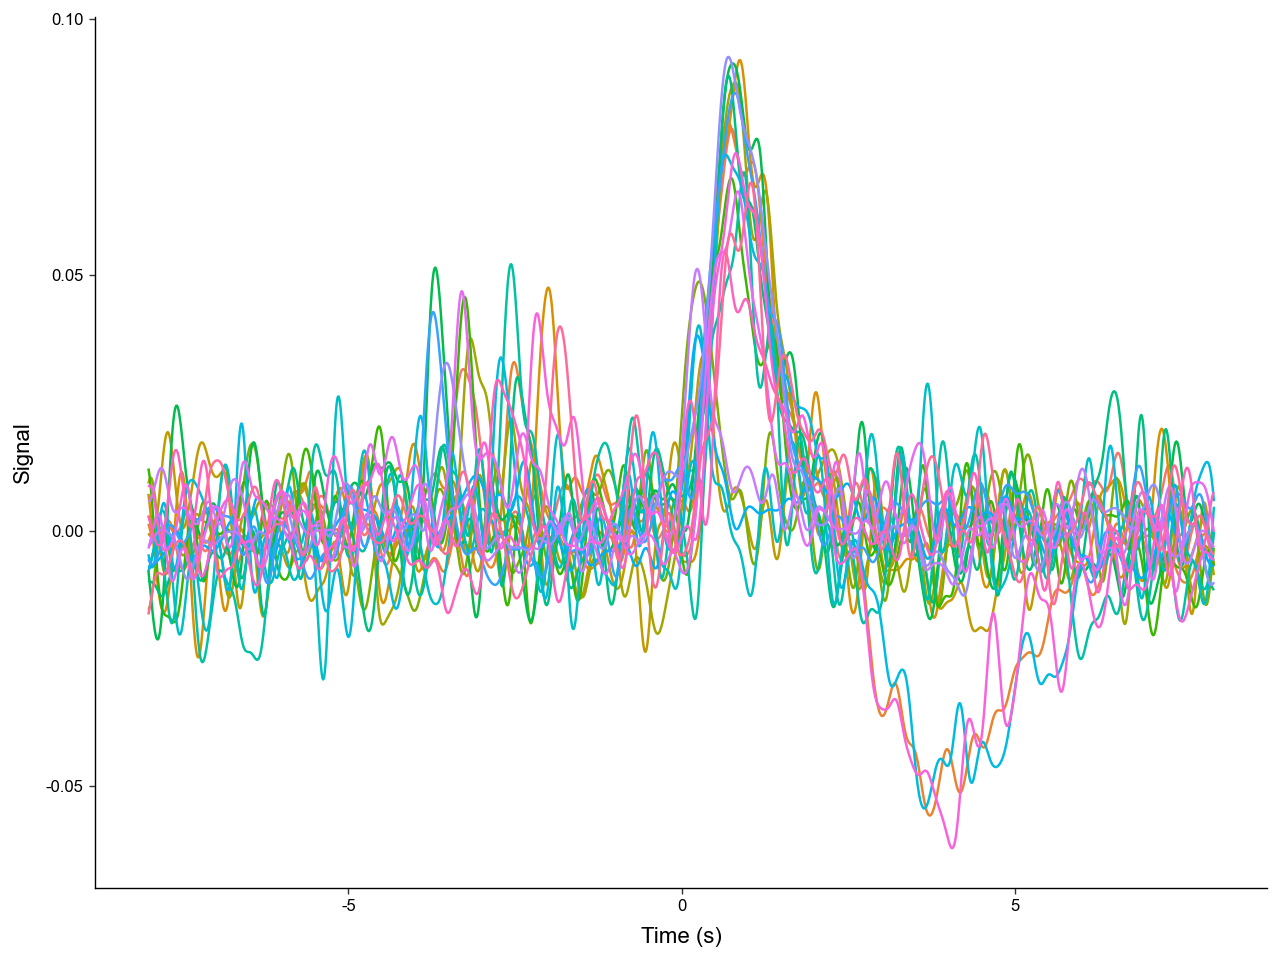

In [26]:
trials.plot_trials()

We can see that there are multiple distinct shapes of trials. Let's catagorize each trial by the events present. We can store this label in ``.obs``. Manipulating and analyzing data often requires the manipulation of ``.obs``.

* ``NoResponse`` corresponds to the subject failing to choose a lever.

* ``type1`` corresponds to the subject choosing the small reward lever ("lever2").

* ``type2`` corresponds to the subject choosing the large reward lever ("lever1") but NOT recieving a shock.

* ``type3`` corresponds to the subject choosing the large reward lever ("lever1") AND recieving a shock.

In [27]:
# we can use a function to manipulate the .obs dataframe
def label_trials(df: pd.DataFrame) -> pd.DataFrame:
    # label trial outcome by event present
    # remeber a NaN value represents a missing event
    has_lever1 = ~df['lever1'].isna()
    has_lever2 = ~df['lever2'].isna()
    has_shock = ~df['shock'].isna()

    df['trial_label'] = pd.NA
    df.loc[has_lever2, 'trial_label'] = 'type1'
    df.loc[has_lever1 & ~has_shock, 'trial_label'] = 'type2'
    df.loc[has_lever1 & has_shock, 'trial_label'] = 'type3'
    df.loc[~has_lever1 & ~has_lever2, 'trial_label'] = 'NoResponse'
    return df

# note the new "trial_label" column
trials.obs = label_trials(trials.obs)
trials.obs.head(5)

,trial_num,trial_cue,lever1,lever2,shock,trial_label
0,1,-3.52,0.0,NaN,NaN,type2
1,2,-2.71,0.0,NaN,1.22,type3
2,3,0.00,NaN,NaN,NaN,NoResponse
3,4,-3.94,0.0,NaN,NaN,type2
4,5,-3.79,0.0,NaN,NaN,type2


Now let's plot the trials again but group them by "trial_label".

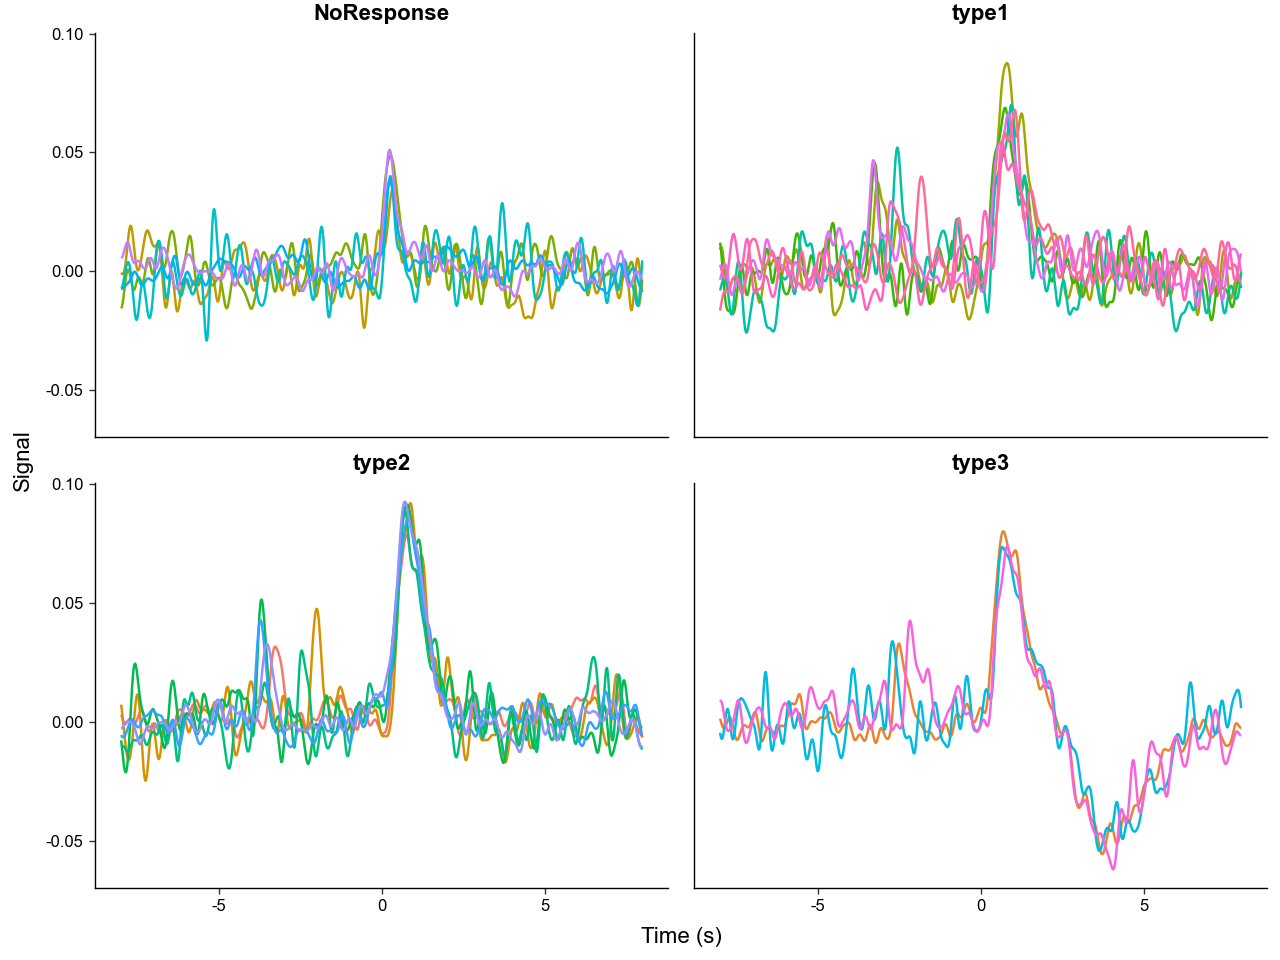

In [28]:
trials.plot_trials(group_on='trial_label')

We can clearly see that the different trial outcomes have different signal architectures. Also note, how the peaks after "trial_cue" are aligned in the "NoResponse" trial type, but spread out in the other trial types, this is because the "NoResponse" trials are aligned to "trial_cue" but the others are aligned to lever presses - meaning there are variable latencies between "trial_cue" and lever presses.

We can quantitativly compare the signal architectures by calculating summary metrics like area under the curve (AUC).

In [29]:
# lets calculate the AUC between 0 and 4.9 seconds
#   but first take the absolute value of the signal before calculation
# this is to capture the notable negative deviation in "type3" trails
trials.obs['AUC_abs'] = trials.area_under_curve(
    centers=0.0,
    bounds=(0, 4.9),
    transformation=np.abs,
)

trials.obs.head(5)

,trial_num,trial_cue,lever1,lever2,shock,trial_label,AUC_abs
0,1,-3.52,0.0,NaN,NaN,type2,0.091611
1,2,-2.71,0.0,NaN,1.22,type3,0.175445
2,3,0.00,NaN,NaN,NaN,NoResponse,0.034675
3,4,-3.94,0.0,NaN,NaN,type2,0.100539
4,5,-3.79,0.0,NaN,NaN,type2,0.108677


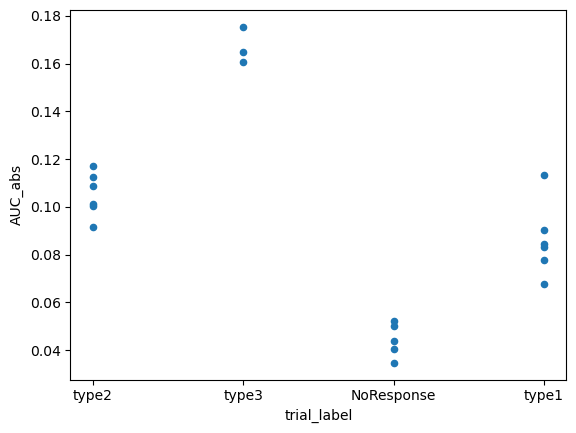

In [30]:
# quick plot using pandas to compare differences in AUC_abs
trials.obs.plot(
    x='trial_label',
    y='AUC_abs',
    kind='scatter',
)
plt.show()

We can directly run an ANOVA with ``.ANOVA()`` to see if the differences are significant.

In [31]:
trials.ANOVA(
    dependent_var='AUC_abs',
    between='trial_label',
)

,Source,SS,DF,MS,F,p_unc,np2
0,trial_label,0.029490,3,0.00983,81.690787,6.460323e-10,0.938714
1,Within,0.001925,16,0.00012,NaN,NaN,NaN


``PhotometryData`` also provides methods to filter out specific trials and average across groups.

We can pass a boolean mask or a sequence of numeric indexes to ``.filter_rows()`` to select the desired trials.

Using ``.collapse`` we can average across groups in ``.obs`` resulting in a new ``PhotometryData`` object.

In [32]:
# filter out "NoResponse" trials
filt_trials = trials.filter_rows(
    trials.obs['trial_label'] != 'NoResponse',
)

# average across trial types
avg = filt_trials.collapse(
    # what .obs columns to group on
    group_on=['trial_label'],

    # what metrics other than mean to compute
    metrics={'std' : np.std},

    # what columns in .obs to also perform the aggregation on
    data_cols=['trial_cue', 'AUC_abs'],

    # what to call the count column
    count_col='n_trials',
)

avg.obs

,trial_label,n_trials,trial_cue,AUC_abs,trial_cue_std,AUC_abs_std
0,type2,6,-3.358333,0.105312,0.644190,0.008474
1,type3,3,-2.680000,0.167020,0.225536,0.006214
2,type1,6,-3.030000,0.086236,0.514101,0.014008


The averaged object now only has 3 trials since we filtered out "NoResponse" trials prior to averaging. ``.X`` is now the average signal and the other metrics that were calculated, like "std", are stored in the ``.layers`` attribute of the underlying adata structure. We can access them with ``.get_layer()``.

In [33]:
avg.get_layer('std')

array([[0.00597655, 0.00586851, 0.00576964, ..., 0.00313776, 0.00303783,
        0.0029651 ],
       [0.00537705, 0.00576166, 0.0060615 , ..., 0.00608109, 0.00547902,
        0.00478708],
       [0.00985744, 0.00949797, 0.00905605, ..., 0.00420562, 0.00432497,
        0.00452045]], shape=(3, 1598))

Now we can plot the average signal for each trial type, with labels and error bars.

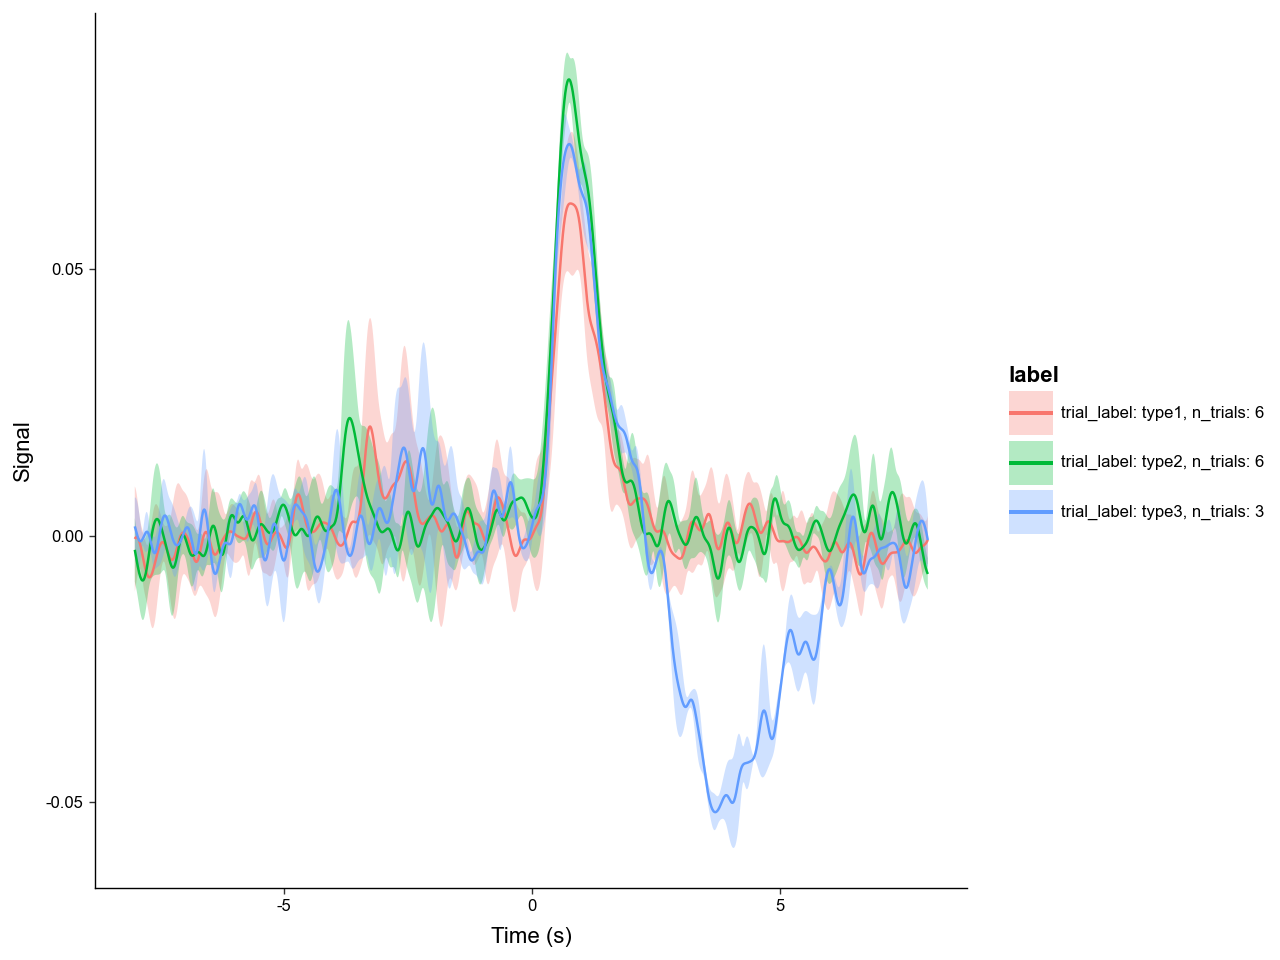

In [34]:
avg.plot_trials(
    label_with=['trial_label', 'n_trials'],
    err_layer='std',
)

What if we want to refocus on the subject's response to "trial_cue"? We can do this with the ``.window()`` method. 

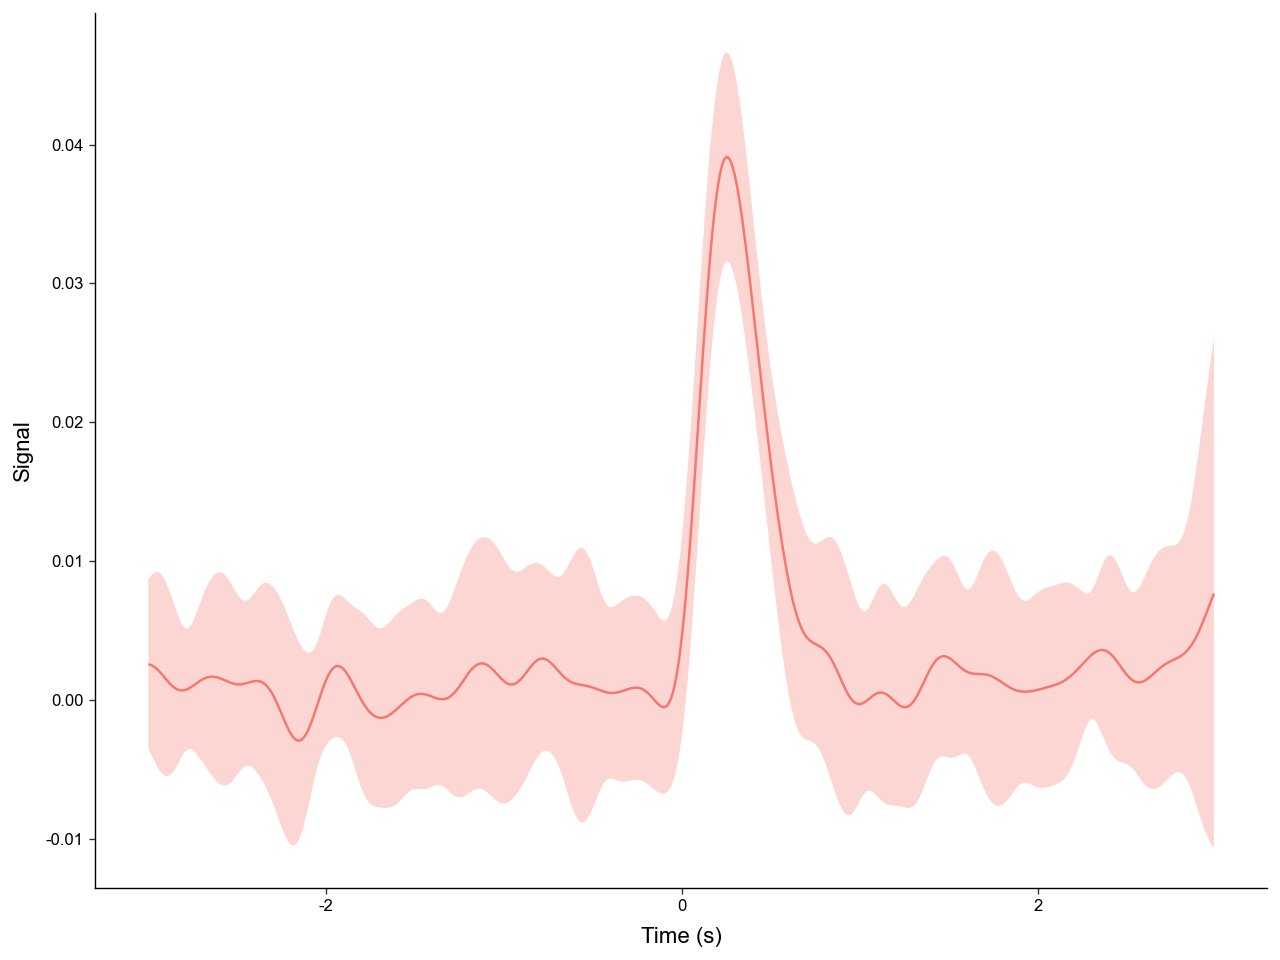

In [35]:
recentered = trials.window(
    # you can pass in a scalar or a sequence of timestamps as centers
    # in this case we are using an event timestamp column in ".obs"
    centers = trials.obs['trial_cue'],
    bounds = (-3, 3),
    # which columns in .obs to also recenter
    event_cols=['trial_cue', 'lever1', 'lever2', 'shock']
)

recentered_avg = recentered.collapse(
    # passing None means all the trials will be averaged
    group_on=None
)

recentered_avg.plot_trials(err_layer='std')

With windowing we can easily get a clean, aligned view of the "trial_cue" peak across trials.

# 5. Bulk Processing

Processing experiments one at a time is all well and good, but often times we need to process dozens to hundreds of experiments. The ``PhotometryPipeline`` class makes batch processing easy.

Take a look in the "data/pipeline/" directory. There you can see two cases of file layouts:

* Case 1: has data (CSV) and annotation (JSON) files seperated in different folders.

* Case 2: has all data (CSV) and annotation (JSON) files in the same directory.

First we will tackle case 1. To use ``PhotometryPipeline`` first you have to initialize the object then run it with specific processing parameters. 

In [36]:
from pyFiberPhotometry import PhotometryPipeline, CSVLoader

# initialize a pipeline object
pipeline1 = PhotometryPipeline(
    # point it to files within the data directory
    data_directory='data/pipeline/case1',
    target_type='file',

    # need to specify which loader to use
    loader_cls=CSVLoader,

    # needs to be recursive to search within subdirectory
    recursive=True,
    pattern='experiment_*.csv'
)

# see what inputs are discovered
pipeline1.discover_inputs()

[PosixPath('data/pipeline/case1/experiment_1/experiment_1.csv'),
 PosixPath('data/pipeline/case1/experiment_3/experiment_3.csv'),
 PosixPath('data/pipeline/case1/experiment_2/experiment_2.csv')]

Now that we have confirmed the inputs are correct, we can run the pipeline by passing in keyword arguments for our selected ``PhotometryLoader``, ``PhotometryExperiment.preprocess_signal()``, and ``PhotometryExperiment.extract_trial_data()``.

In [37]:
from pathlib import Path

# .preprocess_signal() arguments
preprocess_kwargs = dict(
    correction_method = 'dF/F',
    fit_using = 'OLS',
)

# .extract_trial_data() arguments
trial_extraction_kwargs = dict(
    align_to='trial_cue',
    center_on=['lever1', 'lever2'],
    trial_bounds=(-8, 8),
    trial_normalization='none',
    check_overlap=True,
    all_events=True,
)

# loader arguments
# we can pass in loader kwargs as a function that takes in the csv file path
#   so the pipeline can find the annotation files based on the csv path
def case1_loader_kwargs(csv: Path):
    annotation_file = csv.parent / 'annotation.json'
    return dict(
        time_col = 'time',
        signal_col = 'raw_signal',
        isosbestic_col = 'raw_isosbestic',
        event_cols = ['trial_cue', 'lever1', 'lever2', 'shock'],
        annotation_file = annotation_file,
        annotation_handler = 'json',
    )

# run our pipeline
trials: PhotometryData = pipeline1.run(
    # pass in keyword arguments
    loader_kwargs = case1_loader_kwargs,
    preprocess_kwargs = preprocess_kwargs,
    trial_extraction_kwargs = trial_extraction_kwargs,

    # do not automatically save
    output_dir = None,

    # log to a file
    log_file = 'output/example_pipeline_case1.log',

    # passdown metadata loaded from the annotations to .obs
    passdown_metadata = ['source', 'subject', 'sex', 'age']
)

# view output
print(trials)
trials.obs.head(5)

Photometry dataset with 60 trials, 320 timepoints, and 9 observations.


,trial_num,trial_cue,lever1,lever2,shock,source,subject,sex,age
0,1,-3.65,0.0,NaN,1.15,data/pipeline/case1/experiment_1/experiment_1.csv,animal_1,male,young
1,2,-2.70,NaN,0.0,NaN,data/pipeline/case1/experiment_1/experiment_1.csv,animal_1,male,young
2,3,0.00,NaN,NaN,NaN,data/pipeline/case1/experiment_1/experiment_1.csv,animal_1,male,young
3,4,0.00,NaN,NaN,NaN,data/pipeline/case1/experiment_1/experiment_1.csv,animal_1,male,young
4,5,-2.50,NaN,0.0,NaN,data/pipeline/case1/experiment_1/experiment_1.csv,animal_1,male,young


Dealing with case 2 is very similar; however, we do not need to make it recursive and we need to change the loader keyword arguments.

In [38]:
# initialize a pipeline object
pipeline2 = PhotometryPipeline(
    data_directory='data/pipeline/case2',
    target_type='file',
    loader_cls=CSVLoader,

    # does not need to be recursive
    recursive=False,
    pattern='experiment_*.csv'
)

# .preprocess_signal() arguments
preprocess_kwargs = dict(
    correction_method = 'dF/F',
    fit_using = 'OLS',
)

# .extract_trial_data() arguments
trial_extraction_kwargs = dict(
    align_to='trial_cue',
    center_on=['lever1', 'lever2'],
    trial_bounds=(-8, 8),
    trial_normalization='none',
    check_overlap=True,
    all_events=True,
)

# loader arguments
# we can shorten the loader_kwargs function with lambda notation
case2_loader_kwargs = lambda csv: dict(
    time_col = 'time',
    signal_col = 'raw_signal',
    isosbestic_col = 'raw_isosbestic',
    event_cols = ['trial_cue', 'lever1', 'lever2', 'shock'],
    annotation_file = csv.with_suffix('.json'),
    annotation_handler = 'json',
)


# run our pipeline
trials: PhotometryData = pipeline2.run(
    loader_kwargs = case2_loader_kwargs,
    preprocess_kwargs = preprocess_kwargs,
    trial_extraction_kwargs = trial_extraction_kwargs,
    output_dir = None,
    log_file = 'output/example_pipeline_case2.log',
    passdown_metadata = ['source', 'subject', 'sex', 'age']
)

# view output
print(trials)
trials.obs.head(5)

Photometry dataset with 60 trials, 320 timepoints, and 9 observations.


,trial_num,trial_cue,lever1,lever2,shock,source,subject,sex,age
0,1,-3.65,0.0,NaN,1.15,data/pipeline/case2/experiment_1.csv,animal_1,male,young
1,2,-2.70,NaN,0.0,NaN,data/pipeline/case2/experiment_1.csv,animal_1,male,young
2,3,0.00,NaN,NaN,NaN,data/pipeline/case2/experiment_1.csv,animal_1,male,young
3,4,0.00,NaN,NaN,NaN,data/pipeline/case2/experiment_1.csv,animal_1,male,young
4,5,-2.50,NaN,0.0,NaN,data/pipeline/case2/experiment_1.csv,animal_1,male,young


We can also put in custom operations and an unique identifier builder function into the pipeline.

In [39]:
# set up identifier builder
# it needs to be a function that takes in a PhotometryExperiment and returns a string
def build_id(exp: PhotometryExperiment) -> str:
    experiment_num = exp.metadata['source'].split('_')[-1].split('.')[0]
    id = (
        f"exp{experiment_num}_{exp.metadata['subject']}"
    )
    return id

# a pre-signal processing operation
#   that will trim the first ten time points
def post_load_func(exp: PhotometryExperiment) -> None:
    exp.trim_times_by_index(start_idx=10, stop_idx=None)

# a post trial extraction operation
#   that will assign trial labels
def post_extraction_func(exp: PhotometryExperiment) -> None:
    
    df = exp.trial_data.obs

    has_lever1 = ~df['lever1'].isna()
    has_lever2 = ~df['lever2'].isna()
    has_shock = ~df['shock'].isna()

    df['trial_label'] = pd.NA
    df.loc[has_lever2, 'trial_label'] = 'type1'
    df.loc[has_lever1 & ~has_shock, 'trial_label'] = 'type2'
    df.loc[has_lever1 & has_shock, 'trial_label'] = 'type3'
    df.loc[~has_lever1 & ~has_lever2, 'trial_label'] = 'NoResponse'

    exp.trial_data.obs = df

# run our pipeline
trials: PhotometryData = pipeline1.run(
    loader_kwargs = case1_loader_kwargs,
    preprocess_kwargs = preprocess_kwargs,
    trial_extraction_kwargs = trial_extraction_kwargs,
    output_dir = None,
    log_file = 'output/example_pipeline_case3.log',
    passdown_metadata = ['source', 'subject', 'sex', 'age'],

    # pass in functions
    id_builder=build_id,
    post_load_operation=post_load_func,
    post_trial_extraction_operation=post_extraction_func,
)

# view output
print(trials)
trials.obs.head(5)

Photometry dataset with 60 trials, 320 timepoints, and 11 observations.


,trial_num,trial_cue,lever1,lever2,shock,trial_label,experiment_id,source,subject,sex,age
0,1,-3.65,0.0,NaN,1.15,type3,exp1_animal_1,data/pipeline/case1/experiment_1/experiment_1.csv,animal_1,male,young
1,2,-2.70,NaN,0.0,NaN,type1,exp1_animal_1,data/pipeline/case1/experiment_1/experiment_1.csv,animal_1,male,young
2,3,0.00,NaN,NaN,NaN,NoResponse,exp1_animal_1,data/pipeline/case1/experiment_1/experiment_1.csv,animal_1,male,young
3,4,0.00,NaN,NaN,NaN,NoResponse,exp1_animal_1,data/pipeline/case1/experiment_1/experiment_1.csv,animal_1,male,young
4,5,-2.50,NaN,0.0,NaN,type1,exp1_animal_1,data/pipeline/case1/experiment_1/experiment_1.csv,animal_1,male,young


Note the new column "experiment_id" and "trial_label", and the "Running custom operations..." lines in the pipeline log.

For more tutorials please see the other more in depth tutorials on loading data, processing experiments, handling trial-wise data, and simulating photometry data.